# Smoke Test

Verifies the environment works and key pipeline steps produce consistent results.
**This notebook does NOT write any files** — all comparisons are against existing saved data.

In [9]:
import numpy as np
import utils, mass_function, lf_model, lf_optimizer, lf_plotter
from lf_model import FiducialCLF, ReciprocalFuzzyCLF
from lf_optimizer import LFOptimizer
from lf_plotter import LFPlotter
import matplotlib.pyplot as plt
print("All imports OK")

All imports OK


In [10]:
# Load precomputed CDM halo mass functions from mass_fns.npz (read-only)
mf = utils.load_mf()
print(f"Redshifts available: {sorted(mf.keys())}")
print(f"dn/dM(M=1e10, z=6) = {mf[6](1e10):.3e}")
print(f"dn/dM(M=1e9,  z=8) = {mf[8](1e9):.3e}")

Redshifts available: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 13.75, 14, 15, 16, 17, 18, 19]
dn/dM(M=1e10, z=6) = 4.644e-12
dn/dM(M=1e9,  z=8) = 3.605e-10


/root/fdm-uvlf/utils.py:148: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


In [11]:
# Verify mass_fns.npz is consistent with live MassFunction computation.
# MassFunction(load=True) reads P_k.npz and recomputes sigma(M), dndM, etc.
# This does NOT overwrite anything.
mf_live = mass_function.MassFunction(load=True)

print("Comparing saved mass_fns.npz vs live MassFunction.dndM():")
test_points = [(1e9, 6), (1e10, 6), (1e11, 8), (1e9, 10), (1e10, 12)]
for M, z in test_points:
    saved = mf[z](M)
    live = mf_live.dndM(M, z)
    ratio = live / saved
    status = "OK" if 0.9 < ratio < 1.1 else "MISMATCH"
    print(f"  M={M:.0e}, z={z}: saved={saved:.3e}, live={live:.3e}, ratio={ratio:.4f} [{status}]")

Comparing saved mass_fns.npz vs live MassFunction.dndM():
  M=1e+09, z=6: saved=6.967e-10, live=6.959e-10, ratio=0.9989 [OK]
  M=1e+10, z=6: saved=4.644e-12, live=4.647e-12, ratio=1.0006 [OK]
  M=1e+11, z=8: saved=2.373e-15, live=2.397e-15, ratio=1.0102 [OK]
  M=1e+09, z=10: saved=1.445e-10, live=1.445e-10, ratio=0.9998 [OK]
  M=1e+10, z=12: saved=5.136e-14, live=5.170e-14, ratio=1.0065 [OK]


In [12]:
# Instantiate CDM and FDM models using their saved best-fit parameters.
# This is read-only: loads meas.npz and best.npy, evaluates chi-squared.
path = './lf/by_name/'

params_cdm = np.load(path + 'FiducialCLF/best.npy')
model_cdm = FiducialCLF(path + 'FiducialCLF/meas.npz', params_cdm)
print(f"CDM best-fit params: {params_cdm}")
print(f"CDM chi^2 = {model_cdm.chi_sq_of_model():.2f}")
print()

params_fdm = np.load(path + 'ReciprocalFuzzyCLF/best.npy')
model_fdm = ReciprocalFuzzyCLF(path + 'ReciprocalFuzzyCLF/meas.npz', params_fdm)
print(f"FDM param names: {model_fdm.param_names}")
print(f"FDM best-fit params: {params_fdm}")
print(f"FDM chi^2 = {model_fdm.chi_sq_of_model():.2f}")

CDM best-fit params: [  1.69805012   1.54235666   1.12072503 -23.77847008  11.92154453]
CDM chi^2 = 178.83

FDM param names: ['$p$', '$q$', '$r$', '$M_{\\rm UV,0}$', '$\\log_{10}(M_1/$M$_\\odot)$', '$1/m_{22}$']
FDM best-fit params: [ 1.69802680e+00  1.54250505e+00  1.12075324e+00 -2.37785838e+01
  1.19215873e+01  1.86993263e-07]
FDM chi^2 = 178.83


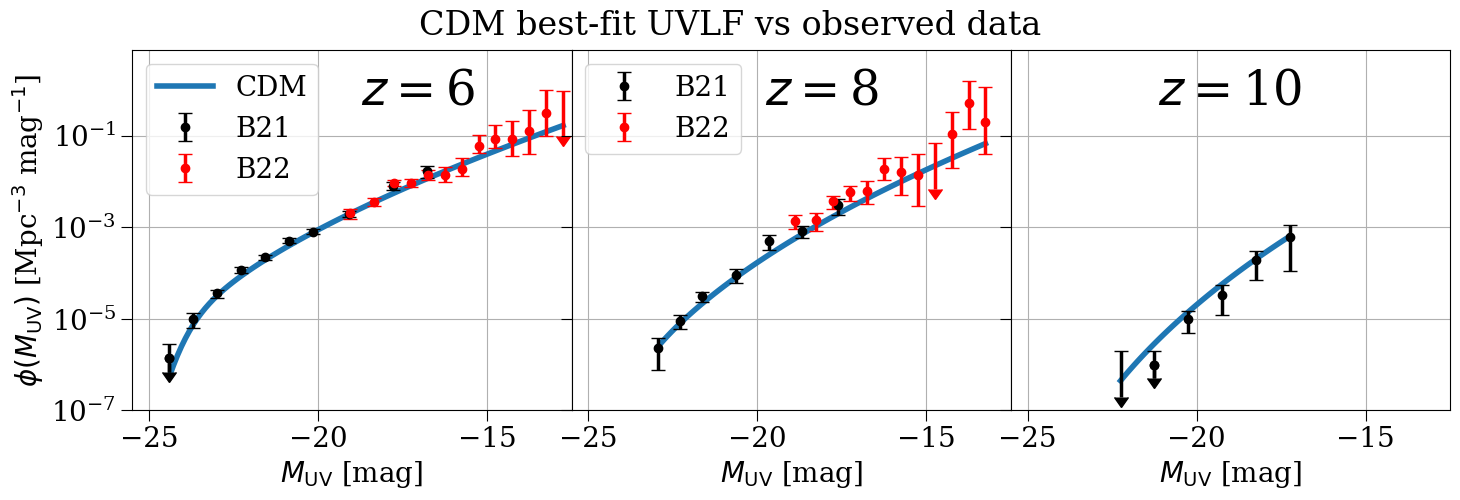

In [13]:
# Plot the UV luminosity function: CDM best-fit model vs data
# Uses LFPlotter which loads best.npy and meas.npz from each directory.
plotter_cdm = LFPlotter(
    [path + 'FiducialCLF'],
    ModelClass=[FiducialCLF],
    names=['CDM']
)
plotter_cdm.plot_fits(eval_z=[6, 8, 10], n_col=3, figsize=(15, 5))
plt.suptitle('CDM best-fit UVLF vs observed data', y=1.02)
plt.show()

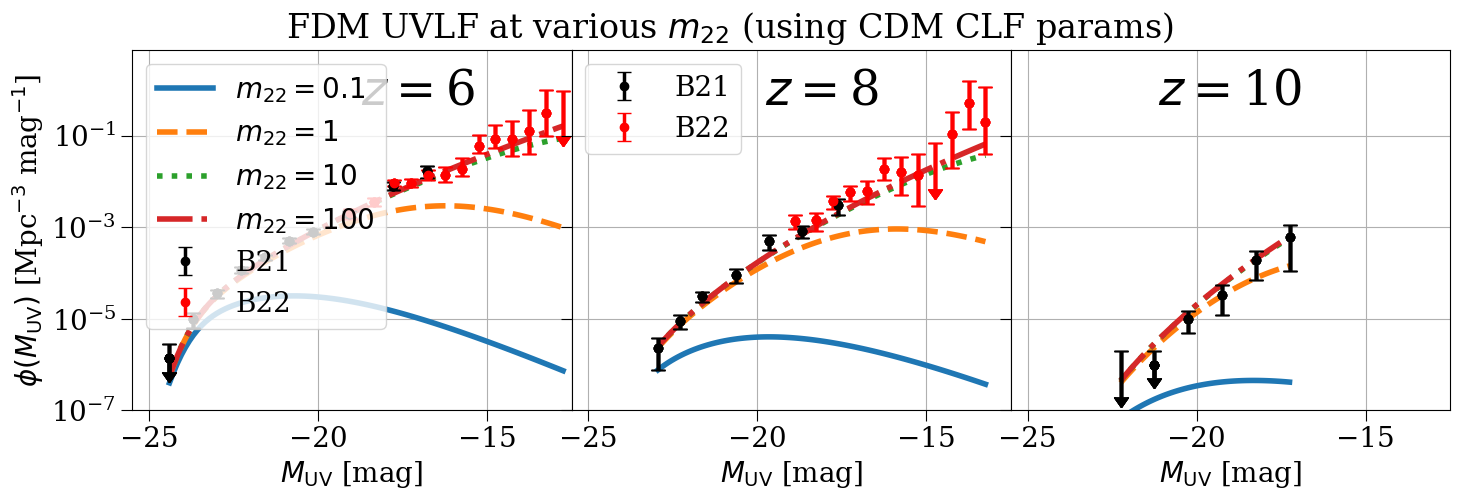

In [14]:
# Show the effect of different FDM masses on the UVLF.
# We use the CDM best-fit CLF parameters but vary m22.
# This shows how suppression increases for lighter FDM particles.
m22_values = [0.1, 1, 10, 100]
cdm_clf_params = params_cdm  # [p, q, r, M_UV0, log10(M1)]

dirs = [path + 'FiducialCLF'] * len(m22_values)
names = [f'$m_{{22}}={m22}$' for m22 in m22_values]
manual_p = [list(cdm_clf_params) + [1.0/m22] for m22 in m22_values]

plotter_fdm = LFPlotter(
    dirs,
    ModelClass=[ReciprocalFuzzyCLF] * len(m22_values),
    names=names,
    manual_params=manual_p
)
plotter_fdm.plot_fits(eval_z=[6, 8, 10], n_col=3, figsize=(15, 5))
plt.suptitle('FDM UVLF at various $m_{22}$ (using CDM CLF params)', y=1.02)
plt.show()

/root/fdm-uvlf/utils.py:148: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


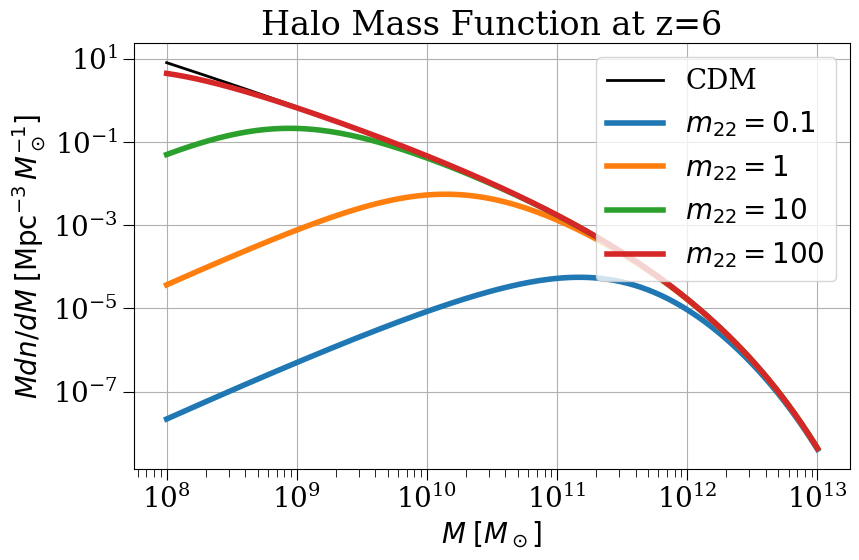

In [23]:
# Halo mass function comparison: CDM vs FDM at different m22
M_vals = np.logspace(8, 13, 200)
plt.figure(figsize=(9, 6))
plt.loglog(M_vals, [M *model_cdm.dn_dM(M, 6) for M in M_vals], 'k-', lw=2, label='CDM')
for m22 in m22_values:
    inv_m22 = 1.0 / m22
    model_at_m22 = ReciprocalFuzzyCLF(
        path + 'FiducialCLF/meas.npz',
        list(cdm_clf_params) + [inv_m22]
    )
    plt.loglog(M_vals, [M * model_at_m22.dn_dM(M, 6) for M in M_vals], label=f'$m_{{22}}={m22}$')
plt.xlabel(r'$M\;[M_\odot]$')
plt.ylabel(r'$M dn/dM\;[{\rm Mpc}^{-3}\,M_\odot^{-1}]$')
plt.legend()
plt.title('Halo Mass Function at z=6')
#plt.ylim(1e-6, None)
plt.tight_layout()
plt.show()

In [16]:
# Run optimizer from saved best-fit (should converge to same values).
# Uses LFOptimizer directly — does NOT save anything to disk.
opt = LFOptimizer(
    meas_fn=path + 'FiducialCLF/meas.npz',
    ModelClass=FiducialCLF,
    x0=params_cdm.copy()
)
result = opt.optimize_loop()
print(f"Converged: {result.success}")
print(f"Optimized chi^2 = {result.fun:.2f}  (saved best-fit gives: {model_cdm.chi_sq_of_model():.2f})")
print(f"Optimized params: {result.x}")
print(f"Saved params:     {params_cdm}")
print(f"Max param diff:   {np.max(np.abs(result.x - params_cdm)):.2e}")

Converged: True
Optimized chi^2 = 178.83  (saved best-fit gives: 178.83)
Optimized params: [  1.69805022   1.54242224   1.12068781 -23.77849291  11.92154874]
Saved params:     [  1.69805012   1.54235666   1.12072503 -23.77847008  11.92154453]
Max param diff:   6.56e-05


In [17]:
# Run a tiny MCMC to verify emcee works. In-memory only — no .h5 file written.
import emcee, os
os.environ['OMP_NUM_THREADS'] = '1'

opt_fdm = LFOptimizer(
    meas_fn=path + 'ReciprocalFuzzyCLF/meas.npz',
    ModelClass=ReciprocalFuzzyCLF,
    x0=params_fdm.copy(),
    prior=ReciprocalFuzzyCLF.MCMC_PRIOR
)

n_walkers, n_dim, n_steps = 16, ReciprocalFuzzyCLF.N_PARAMS, 100
pos = np.random.normal(scale=0.05, size=(n_walkers, n_dim)) + opt_fdm.x0
sampler = emcee.EnsembleSampler(n_walkers, n_dim, opt_fdm.log_prob)
sampler.run_mcmc(pos, n_steps, progress=True)

print(f"\nChain shape: {sampler.get_chain().shape}  (steps, walkers, params)")
print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.2f}")

/root/fdm-uvlf/lf_model.py:866: RuntimeWarning: invalid value encountered in scalar power
  self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)
You must install the tqdm library to use progress indicators with emcee
/root/anaconda3/envs/fdm-req-test/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



Chain shape: (100, 16, 6)  (steps, walkers, params)
Mean acceptance fraction: 0.44


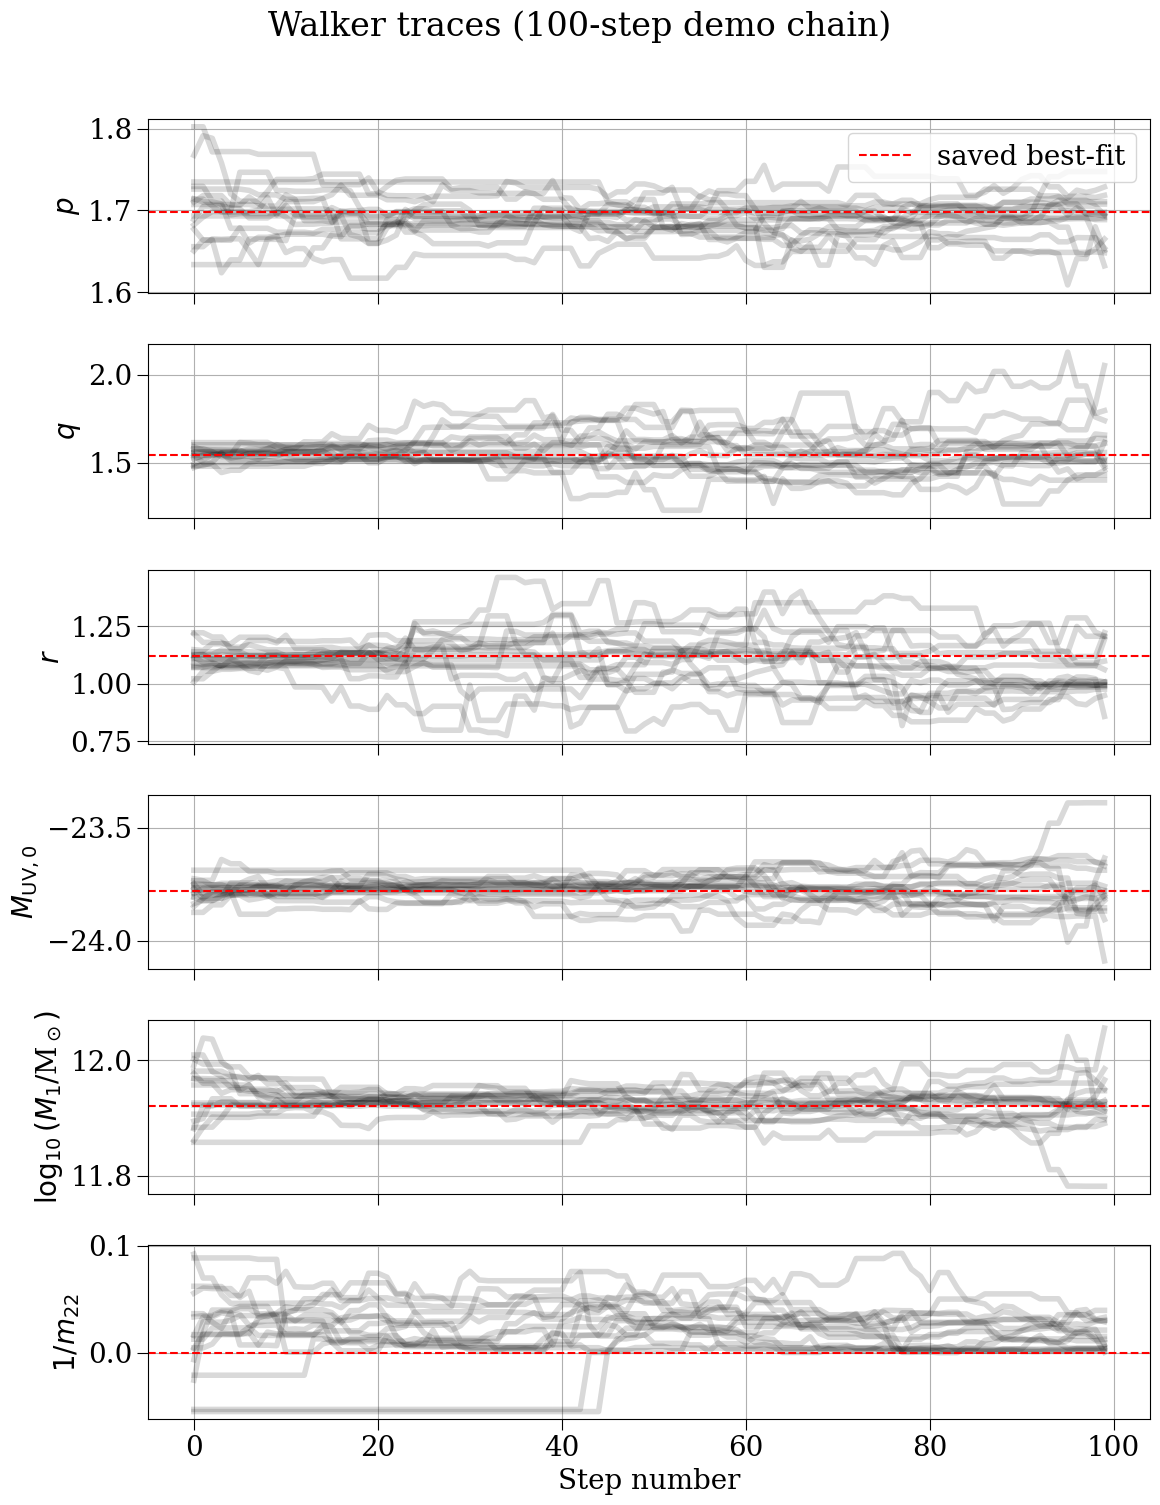

In [18]:
# Plot walker traces (chain progress over time)
# This shows whether walkers are mixing and converging.
chain = sampler.get_chain()  # shape: (n_steps, n_walkers, n_dim)
fig, axes = plt.subplots(n_dim, figsize=(12, 2.5 * n_dim), sharex=True)
labels = model_fdm.param_names

for i in range(n_dim):
    ax = axes[i]
    ax.plot(chain[:, :, i], 'k', alpha=0.15)
    ax.axhline(params_fdm[i], color='red', ls='--', lw=1.5, label='saved best-fit')
    ax.set_ylabel(labels[i])
    if i == 0:
        ax.legend(loc='upper right')
axes[-1].set_xlabel('Step number')
plt.suptitle('Walker traces (100-step demo chain)', y=1.01)
plt.tight_layout()
plt.show()

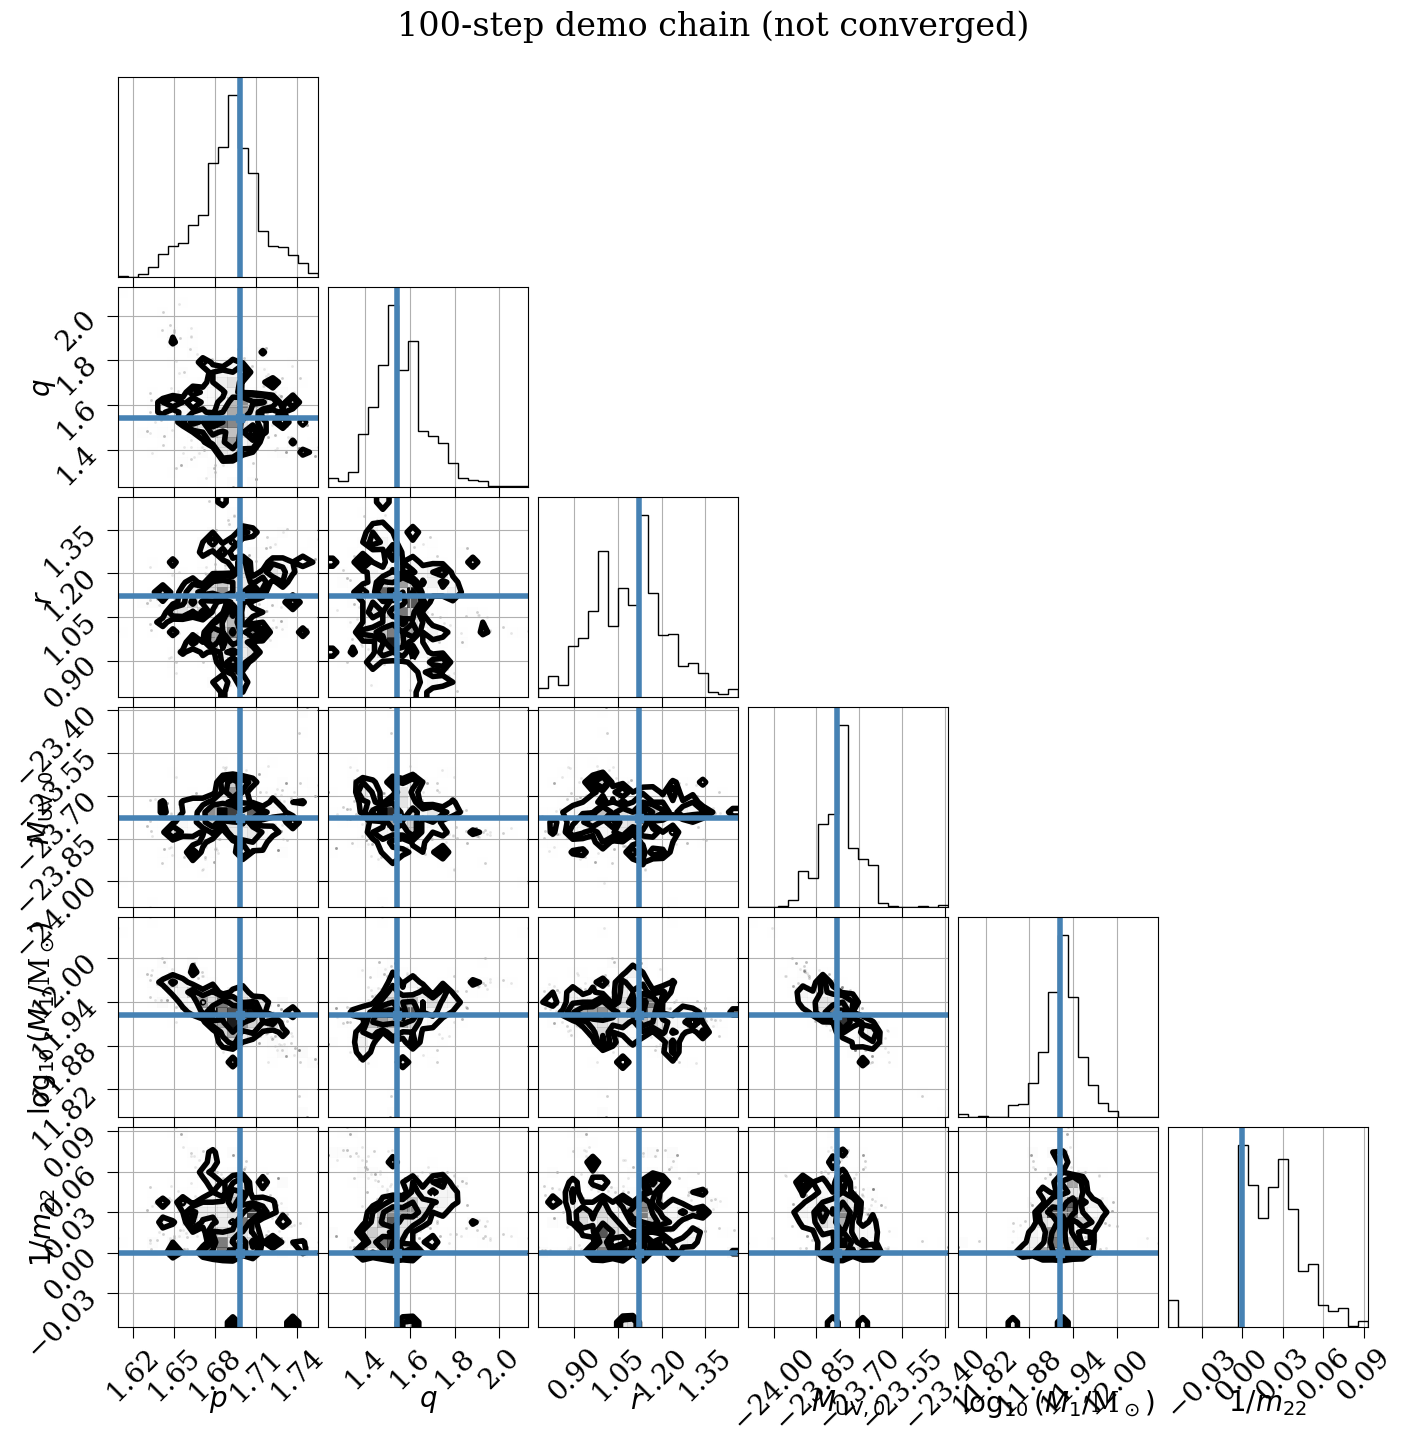

In [19]:
# Corner plot from the short chain (won't be converged — just proves the pipeline)
import corner
flat_samples = sampler.get_chain(discard=30, flat=True)
fig = corner.corner(flat_samples, labels=model_fdm.param_names, truths=params_fdm)
plt.suptitle('100-step demo chain (not converged)', y=1.02)
plt.show()

## Summary

If all cells above ran without errors:
- Environment is set up correctly
- `mass_fns.npz` and `P_k.npz` are consistent with each other
- Model instantiation, chi-squared evaluation, optimizer, and MCMC all work
- No files were modified

### Key pattern for new models

To plug in your own halo mass function, subclass `LFModel` and override `dn_dM(self, M, z)`:

```python
class MyCustomCLF(LFModel):
    N_PARAMS = ...  # number of free parameters
    MCMC_PRIOR = [...]  # bounds for each param
    
    def __init__(self, meas_fn, params, ...):
        super().__init__(meas_fn, params, ...)
        # unpack your params here
    
    def dn_dM(self, M, z):
        # Your custom halo mass function
        # self.mass_fn[z](M) gives the CDM baseline
        return self.mass_fn[z](M) * your_suppression(M, z)
    
    def L_c(self, M, z):
        # Conditional luminosity function (can copy from FiducialCLF)
        return np.clip(
            self.L0 * (M/self.M1)**self.p / (1 + (M/self.M1)**self.q) * ((1+z)/7)**self.r,
            a_max=self.L_c_max(M, z), a_min=0
        )
```

Then pass it to `LFOptimizer(ModelClass=MyCustomCLF, ...)` and run `.optimize_loop()` or feed to `emcee`.